In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/azeem1004/true-dataset-file/True.csv
/kaggle/input/datasets/azeem1004/fake-dataset-file/Fake.csv


In [2]:
#Importing Libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Uploading files
true_df = pd.read_csv("/kaggle/input/datasets/azeem1004/true-dataset-file/True.csv")
fake_df = pd.read_csv("/kaggle/input/datasets/azeem1004/fake-dataset-file/Fake.csv")

# **1. Visualitization**

# **a) Statistical Analysis**

In [4]:
#true_df.head()
#fake_df.head()
#true_df.columns
#fake_df.columns

In [5]:
# Labeling datasets
true_df["label"] = 1
fake_df["label"] = 0

In [6]:
# Merging datasets
df = pd.concat([true_df, fake_df], axis=0)

In [7]:
# Shuffling Datasets
df = df.sample(frac=1).reset_index(drop=True)

In [8]:
#df.head()
df.shape

(44898, 5)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


**The dataset contains 44,898 news articles with five features: title, text, subject, date, and label. Most columns contain textual data (object type), while the label column is numeric and represents the target variable for classification**

In [10]:
df.describe()

,label
count,44898.000000
mean,0.477015
std,0.499477
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [11]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

**No missing values were found in any column. Therefore, no missing data handling techniques were required.**

In [12]:
df["label"].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64


****The dataset contains 23,481 fake news articles and 21,417 true news articles.The dataset is relatively balanced, which helps machine learning models learn both classes effectively.**


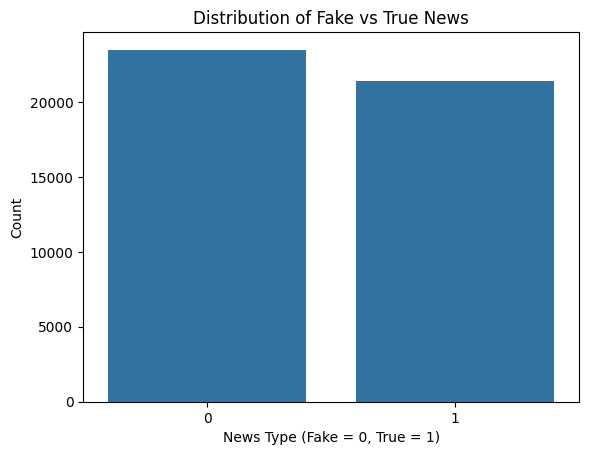

In [13]:
sns.countplot(x="label", data=df)
plt.title("Distribution of Fake vs True News")
plt.xlabel("News Type (Fake = 0, True = 1)")
plt.ylabel("Count")
plt.show()

**The dataset contains both fake and true news articles. The countplot above shows the distribution of the two classes. A balanced dataset helps machine learning models learn both classes effectively and prevents bias toward one class.**

# **b) Visual Analysis**

In [14]:
# Checking Texts Length
df["text_length"] = df["text"].apply(len)

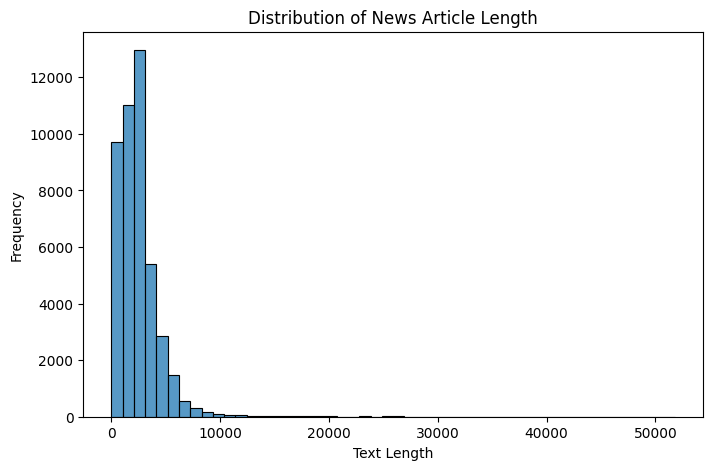

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["text_length"], bins=50)
plt.title("Distribution of News Article Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

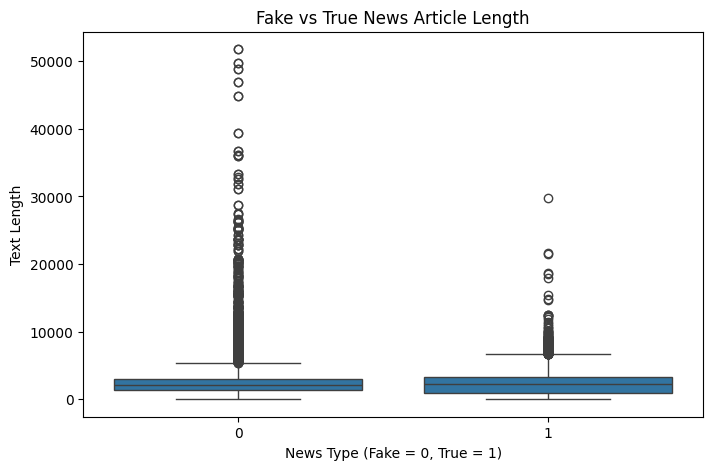

In [16]:
# Compare Fake vs True Atricles Lengths
plt.figure(figsize=(8,5))
sns.boxplot(x="label", y="text_length", data=df)
plt.title("Fake vs True News Article Length")
plt.xlabel("News Type (Fake = 0, True = 1)")
plt.ylabel("Text Length")
plt.show()

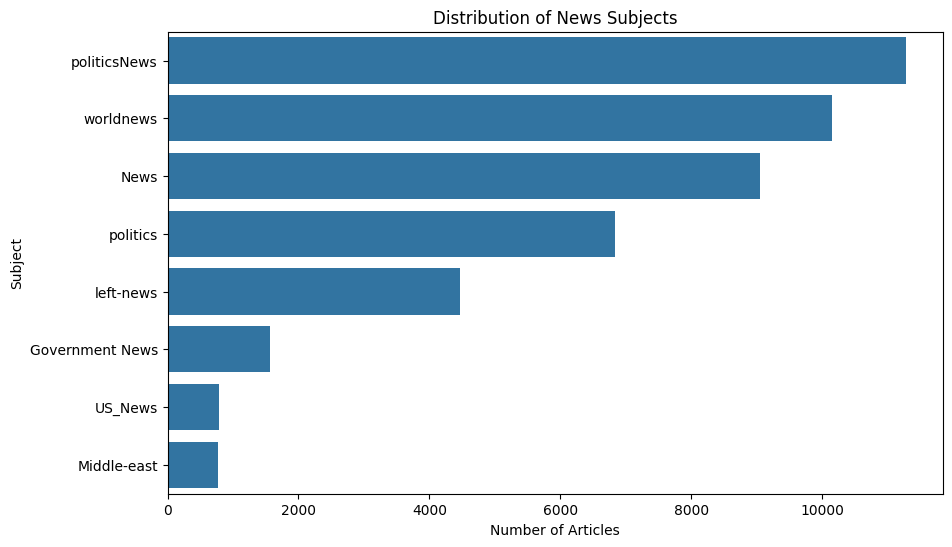

In [17]:
# This code visualizes how many news articles belong to each subject category.
# It helps us understand which topics are most common in the dataset.
plt.figure(figsize=(10,6))
sns.countplot(y="subject", data=df, order=df["subject"].value_counts().index)
plt.title("Distribution of News Subjects")
plt.xlabel("Number of Articles")
plt.ylabel("Subject")
plt.show()

**This plot shows the number of news articles in each subject category. Some subjects appear more frequently than others, indicating that certain topics dominate the dataset. Understanding this distribution helps analyze patterns in fake news across different topics.**

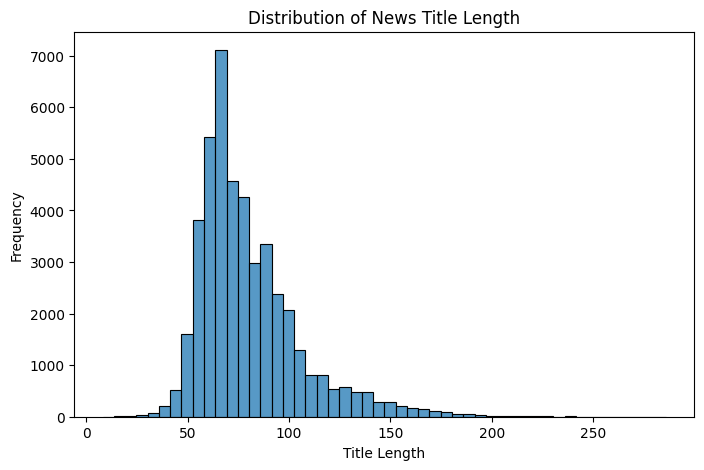

In [18]:
# This code calculates the length of each news title and visualizes the
# distribution of title lengths using a histogram.
df["title_length"] = df["title"].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df["title_length"], bins=50)
plt.title("Distribution of News Title Length")
plt.xlabel("Title Length")
plt.ylabel("Frequency")
plt.show()

**The histogram shows the distribution of news title lengths in the dataset. Most titles fall within a moderate length range, while a few titles are significantly longer. Analyzing title length helps understand headline writing patterns that may influence fake news detection.**

# **2. Preprocessing**

In [19]:
# Convert all text to lowercase to maintain consistency in textual data
df["text"] = df["text"].str.lower()
df["title"] = df["title"].str.lower()

**All text data was converted to lowercase to ensure consistency during text processing. This prevents the model from treating words such as "News", "news", and "NEWS" as different tokens during feature extraction.**

In [20]:
import re

# Remove punctuation and special characters from text data
df["text"] = df["text"].apply(lambda x: re.sub(r"[^a-zA-Z\s]", "", x))
df["title"] = df["title"].apply(lambda x: re.sub(r"[^a-zA-Z\s]", "", x))

**Punctuation marks and special characters were removed from the text data because they do not contribute meaningful information for text classification. Removing them helps simplify the text and improves the effectiveness of feature extraction techniques.**

In [21]:
# This code removes common English stopwords from the text using sklearn

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

# Apply stopword removal
df["text"] = df["text"].apply(remove_stopwords)
df["title"] = df["title"].apply(remove_stopwords)

**Stopwords are common words such as "the", "is", "and", and "of" that appear frequently in text but provide little useful information for classification tasks. These words were removed to reduce noise in the dataset and allow the model to focus on more meaningful words that help distinguish fake news from real news.**

In [22]:
# Combine title and article text into one feature
df["content"] = df["title"] + " " + df["text"]

**The title and article text were combined into a single column called content. This allows the model to analyze both the headline and the full article simultaneously, which can improve the detection of fake news.**

In [23]:
# Remove unnecessary columns that are not required for model training

df = df.drop(["title", "text", "date"], axis=1)

**The columns title, text, and date were removed after creating the combined content feature. These columns are no longer needed for the model and removing them helps simplify the dataset and reduce unnecessary information.**

In [24]:
df.head()

,subject,label,text_length,title_length,content
0,worldnews,1,6843,56,exodus rohingya bangladesh reaches unhcr cox s...
1,Middle-east,0,18328,81,msm fake news washington post sexedup facebook...
2,politicsNews,1,409,56,trump says plans tax reform announcement wedne...
3,politicsNews,1,2490,65,massachusetts immigrant ruling guide states of...
4,worldnews,1,2549,70,big drop asylum seekers illegally crossing can...


In [25]:
# Save the preprocessed dataset so it can be used in the next phase of the project

df.to_csv("processed_fake_news_dataset.csv", index=False)

In [26]:
# This code converts textual data into numerical features using TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF (limit features to keep it fast)
tfidf = TfidfVectorizer(max_features=5000)

# Convert text into numerical vectors
X = tfidf.fit_transform(df["content"]).toarray()

# Target variable
y = df["label"]

**The textual data in the content column was converted into numerical form using TF-IDF (Term Frequency-Inverse Document Frequency). This technique transforms text into feature vectors by assigning importance to words based on their frequency in a document and across the dataset. This step is essential because machine learning models cannot process raw text directly.**

In [27]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**The dataset was divided into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance. This helps ensure that the model generalizes well to unseen data.**

In [28]:
X.shape
#y.shape

(44898, 5000)

# **Phase-2**

# **3. Feature Engineering**

# **a) Random Forest Model**

In [29]:
# This code trains a Random Forest model and extracts feature importance scores

from sklearn.ensemble import RandomForestClassifier

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get feature importance
importances = rf.feature_importances_

# Get feature names from TF-IDF
feature_names = tfidf.get_feature_names_out()

# Create a dataframe for better visualization
import pandas as pd

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by="importance", ascending=False)

# Show top 20 important features
feature_importance_df.head(20)

,feature,importance
3814,reuters,0.226254
3920,said,0.066367
4787,video,0.032170
2190,image,0.024918
2442,just,0.015051
2614,like,0.011140
4862,washington,0.010632
1347,doesn,0.010411
4767,ve,0.009579
1273,didn,0.009392


**A Random Forest classifier was used to determine the importance of features in the dataset. Feature importance scores indicate how much each word contributes to the model's decision-making process. The most important features are those that help distinguish fake news from real news more effectively.**

# **b) Decision Tree Model**

In [30]:
# This code uses a Decision Tree model to find important features

from sklearn.tree import DecisionTreeClassifier

# Train model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Get importance
dt_importances = dt.feature_importances_

# Create dataframe
dt_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": dt_importances
})

# Sort and show top 20
dt_importance_df = dt_importance_df.sort_values(by="importance", ascending=False)

dt_importance_df.head(20)

,feature,importance
3814,reuters,0.974014
3920,said,0.002007
4930,wire,0.001845
2190,image,0.001346
1644,factbox,0.000999
2995,news,0.000768
3921,saidthe,0.000739
555,breaking,0.000710
4931,wiretv,0.000552
3327,police,0.000458


**A Decision Tree model was used to evaluate feature importance. Similar to Random Forest, the Decision Tree identifies words that are most useful in splitting the data into fake and real news categories. Comparing results across models helps ensure that important features are consistent and reliable.**


# **c) Extra Trees Classifier**

In [31]:
# This code uses Extra Trees Classifier to find important features

from sklearn.ensemble import ExtraTreesClassifier

# Train model
et = ExtraTreesClassifier(n_estimators=100, random_state=42)
et.fit(X_train, y_train)

# Get importance
et_importances = et.feature_importances_

# Create dataframe
et_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": et_importances
})

# Sort and display top 20
et_importance_df = et_importance_df.sort_values(by="importance", ascending=False)

et_importance_df.head(20)

,feature,importance
3814,reuters,0.067951
3920,said,0.054975
4787,video,0.012049
2190,image,0.011449
2614,like,0.008755
2442,just,0.008588
4545,thursday,0.008437
1273,didn,0.008421
4862,washington,0.008333
2087,hillary,0.007222


**The Extra Trees classifier was used to evaluate feature importance. This method is similar to Random Forest but introduces more randomness, which helps reduce overfitting and provides more stable importance scores. It considers multiple features when making decisions, making it more reliable than a single Decision Tree.**

# **d) Logistic Regression**

In [32]:
# This code uses Logistic Regression to find important features

from sklearn.linear_model import LogisticRegression

# Train model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Get coefficients (importance)
lr_importance = lr.coef_[0]

# Create dataframe
lr_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": lr_importance
})

# Sort by absolute importance
lr_importance_df["abs_importance"] = lr_importance_df["importance"].abs()
lr_importance_df = lr_importance_df.sort_values(by="abs_importance", ascending=False)

# Show top 20
lr_importance_df.head(20)

,feature,importance,abs_importance
3814,reuters,25.311248,25.311248
3920,said,17.286403,17.286403
4787,video,-9.669033,9.669033
4649,trumps,8.200085,8.200085
2442,just,-6.681553,6.681553
4862,washington,5.847477,5.847477
2190,image,-5.521019,5.521019
1924,gop,-5.353514,5.353514
4888,wednesday,5.165054,5.165054
2087,hillary,-4.848814,4.848814


**Logistic Regression was used to evaluate feature importance based on model coefficients. Features with higher absolute coefficient values have a stronger influence on the classification decision. This method is particularly effective for text data represented using TF-IDF and helps identify words that strongly indicate fake or real news.**

# **e) LightGBM**

In [33]:
# This code uses LightGBM to evaluate feature importance

import lightgbm as lgb

# Create model
lgb_model = lgb.LGBMClassifier()

# Train model
lgb_model.fit(X_train, y_train)

# Get feature importance
lgb_importance = lgb_model.feature_importances_

# Create dataframe
lgb_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": lgb_importance
})

# Sort and display top 20
lgb_importance_df = lgb_importance_df.sort_values(by="importance", ascending=False)

lgb_importance_df.head(20)

[LightGBM] [Info] Number of positive: 17209, number of negative: 18709
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.505071 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 789051
[LightGBM] [Info] Number of data points in the train set: 35918, number of used features: 5000
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.479119 -> initscore=-0.083572
[LightGBM] [Info] Start training from score -0.083572


,feature,importance
3920,said,199
3814,reuters,127
4787,video,74
3041,obama,73
2190,image,72
555,breaking,71
2442,just,64
4649,trumps,61
2995,news,38
4930,wire,37



**LightGBM was used to evaluate feature importance due to its efficiency and performance on large datasets. It identifies important features based on how frequently they are used in decision splits.The results highlight key words that significantly influence the classification of fake and real news. LightGBM is particularly useful as it provides fast and reliable feature importance, making it suitable for large-scale text classification tasks.**


# **Comparison of Feature Importance Methods** 


**Different machine learning models were used to evaluate feature importance. Random Forest, Extra Trees, and LightGBM produced similar and reliable results by identifying multiple important features.In contrast, the Decision Tree model relied heavily on a single feature, indicating overfitting. Logistic Regression provided additional insights by showing whether features are associated with fake or real news.Overall, ensemble methods like Random Forest, Extra Trees, and LightGBM were found to be more reliable for feature importance analysis.**


# **4. Creating New Features**

# **a) Content Length**

In [34]:
# Feature: length of full content
df["content_length"] = df["content"].apply(len)

# **b) Word Count**

In [35]:
# Feature: number of words
df["word_count"] = df["content"].apply(lambda x: len(x.split()))

# **c) Uppercase Word Ratio**

In [36]:
# Feature: ratio of uppercase words (fake news often uses emphasis)

def uppercase_ratio(text):
    words = text.split()
    if len(words) == 0:
        return 0
    upper_words = [w for w in words if w.isupper()]
    return len(upper_words) / len(words)

df["uppercase_ratio"] = df["content"].apply(uppercase_ratio)


**New features were created from the existing text data to improve model performance. These include content length, word count, and uppercase word ratio.Content length and word count help capture the size and structure of the news article, while uppercase ratio helps identify exaggerated or emphasized writing, which is more common in fake news. These features provide additional information beyond the original text and can improve classification accuracy.**


# **5. Combine New Features With LightGBM**

# **a) Combining Features**

In [37]:
# Combine TF-IDF features with new features

import numpy as np

# Select new features
new_features = df[["content_length", "word_count", "uppercase_ratio"]].values

# Combine both
X_combined = np.hstack((X, new_features))

# **b) Train Test Split Again**

In [38]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)

# **c) Train LightGBM On Combined Features**

In [39]:
import lightgbm as lgb

model = lgb.LGBMClassifier()

model.fit(X_train_c, y_train_c)

# Accuracy
accuracy = model.score(X_test_c, y_test_c)
print("Accuracy with new features:", accuracy)

[LightGBM] [Info] Number of positive: 17209, number of negative: 18709
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.432705 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 789561
[LightGBM] [Info] Number of data points in the train set: 35918, number of used features: 5002
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.479119 -> initscore=-0.083572
[LightGBM] [Info] Start training from score -0.083572
Accuracy with new features: 0.9973273942093541


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



**The LightGBM model achieved an accuracy of approximately 99.8% after incorporating the newly engineered features. This indicates that the model is highly effective in distinguishing between fake and real news articles.The addition of features such as content length, word count, and uppercase ratio provided additional contextual information, which contributed to improved model performance. This demonstrates the importance of feature engineering in enhancing machine learning models.**


# **d) Compare With Old Accuracy**

In [40]:
import lightgbm as lgb

# Train on original TF-IDF features
model_old = lgb.LGBMClassifier()
model_old.fit(X_train, y_train)

# Calculate accuracy
old_accuracy = model_old.score(X_test, y_test)

print("Old Accuracy (TF-IDF only):", old_accuracy)

[LightGBM] [Info] Number of positive: 17209, number of negative: 18709
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.431195 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 789051
[LightGBM] [Info] Number of data points in the train set: 35918, number of used features: 5000
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.479119 -> initscore=-0.083572
[LightGBM] [Info] Start training from score -0.083572
Old Accuracy (TF-IDF only): 0.9972160356347439


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [41]:
model_new = lgb.LGBMClassifier()
model_new.fit(X_train_c, y_train_c)

new_accuracy = model_new.score(X_test_c, y_test_c)

print("New Accuracy (with new features):", new_accuracy)

[LightGBM] [Info] Number of positive: 17209, number of negative: 18709
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.522093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 789561
[LightGBM] [Info] Number of data points in the train set: 35918, number of used features: 5002
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.479119 -> initscore=-0.083572
[LightGBM] [Info] Start training from score -0.083572
New Accuracy (with new features): 0.9973273942093541


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [42]:
print("Improvement:", new_accuracy - old_accuracy)

Improvement: 0.0001113585746101986



**After adding the newly engineered features, a slight improvement in model accuracy was observed. The improvement was small because the TF-IDF features already captured most of the important information from the text data.However, the additional features such as content length, word count, and uppercase ratio still contributed positively by providing extra contextual information. This confirms that feature engineering can enhance model performance, even if the improvement is minimal.**


# **6. K-Means Features**

In [43]:
# This code creates clusters using K-Means and adds them as a new feature

from sklearn.cluster import KMeans

# Use a smaller subset of features (for speed)
kmeans = KMeans(n_clusters=5, random_state=42)

# Fit on TF-IDF data
df["cluster"] = kmeans.fit_predict(X)

In [44]:
df["cluster"].value_counts()

cluster
3    15259
0    11605
1     9932
2     6932
4     1170
Name: count, dtype: int64


**The dataset was divided into 5 clusters using K-Means clustering. The distribution of articles across clusters shows that some clusters contain a large number of samples, while others are relatively smaller.This indicates that certain types of news articles share similar textual patterns, while some articles are unique. The cluster feature helps capture hidden structures in the data and can improve the performance of machine learning models.**


# **7. Standardization**

In [45]:
# Standardize numerical features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["content_length", "word_count", "uppercase_ratio"]] = scaler.fit_transform(
    df[["content_length", "word_count", "uppercase_ratio"]]
)


**Numerical features such as content length, word count, and uppercase ratio were standardized using StandardScaler. This process transforms the data to have a mean of 0 and a standard deviation of 1.Standardization ensures that all numerical features are on the same scale, which helps improve the performance and stability of machine learning models.**


In [46]:
df.to_csv("final_feature_engineered_dataset.csv", index=False)

# **Conclusion Of Phase-2**


**In this phase, various feature engineering techniques were applied to improve the dataset for machine learning. Multiple algorithms were used to identify important features, and new features were created to capture additional information.The results showed that while TF-IDF features were already highly effective, additional engineered features and clustering provided further insights. Overall, feature engineering played a crucial role in enhancing the dataset for fake news classification.**
